In [1]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, top_k_accuracy_score
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize
import pandas as pd
from matplotlib_venn import venn3, venn3_circles
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from itertools import cycle
import unicodedata
import ast, glob, os
from matplotlib import font_manager, rcParams
from matplotlib.lines import Line2D

# Path to your font directory
font_dir = "/data1/morrisq/yuj13/share/fonts/liberation-fonts-ttf-2.1.5/"

# Register the font files with Matplotlib
font_manager.fontManager.addfont(font_dir + "LiberationSans-Regular.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Bold.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Italic.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-BoldItalic.ttf")

# Set Liberation Sans as the default font (Arial-compatible)
rcParams["font.family"] = "Liberation Sans"

In [2]:
def _palette3(palette="set2"):
    """Return 3 pretty colors."""
    maps = {
        "set2": plt.cm.Set2,
        "pastel1": plt.cm.Pastel1,
        "tab10": plt.cm.tab10,
        "deep": plt.cm.Dark2,
    }
    if isinstance(palette, (list, tuple)) and len(palette) >= 3:
        return palette[:3]
    cmap = maps.get(str(palette).lower(), plt.cm.Set2)
    return [cmap(i) for i in range(3)]

def myVenn(df, c1, c2, c3, savepath=None):
    # Pastel color palette like your example (blue, orange, green)
    venn_colors = ["#8DA0CB", "#FDBF6F", "#66C2A5"]
    # venn_colors = ["#A6CEE3", "#FDBF6F", "#B2DF8A"]
    df[f"{c1}_set"] = df[c1] + df['SAMPLE_ID']
    df[f"{c2}_set"] = df[c2] + df['SAMPLE_ID']
    df[f"{c3}_set"] = df[c3] + df['SAMPLE_ID']

    plt.figure(figsize=(9, 8))
    venn = venn3(
        subsets=([set(df[f"{c1}_set"]), set(df[f"{c2}_set"]), set(df[f"{c3}_set"])]),
        set_labels=(c1.replace("_", " "), c2.replace("_", " "), c3.replace("_", " ")),
        set_colors=venn_colors,
        alpha=0.6
    )

    venn3_circles(
        subsets=([set(df[f"{c1}_set"]), set(df[f"{c2}_set"]), set(df[f"{c3}_set"])]),
        linestyle="solid", linewidth=1.2, color="gray"
    )

    ## white labels inside areas
    total = len(df)
    region_codes = ['001', '010', '100', '011', '110', '101', '111']
    
    for code in region_codes:
        lbl = venn.get_label_by_id(code)
        if lbl and int(lbl.get_text()) > 0:
            pct = f"{int(lbl.get_text())/total:.1%}"
            lbl.set_text(f"{int(lbl.get_text())}\n{pct}")
            lbl.set_fontsize(16)
            lbl.set_color("gray")   # white like your example
            lbl.set_weight("bold")
    
    # set labels (A, B, C)
    for lbl in venn.set_labels:
        if lbl:
            lbl.set_fontsize(20)
            lbl.set_weight("bold")
            lbl.set_color("black")
    if savepath:
        plt.savefig(savepath)
    plt.show()
    
def normalize(name):
    # Normalize unicode (e.g., replace en dash/em dash with hyphen)
    name = unicodedata.normalize('NFKD', name)
    name = name.replace('‑', '-')  # non-breaking hyphen
    name = name.replace('‐', '-')  # hyphen
    name = name.replace('–', '-')  # en dash
    name = name.replace('—', '-')  # em dash
    name = name.replace(',', '')  # remove commas
    # name = name.strip().lower()  # lowercase for uniformity
    return name

## Load results

In [3]:
"""Load and prepare the genomic data for analysis."""
# Define paths
gdd_path = "/data1/morrisq/yuj13/llm_genomics/genie_output/GDD-ENS/filtered_batch_msk"
o3_mini_path = "/data1/morrisq/yuj13/llm_genomics/genie_output/gpt-5/filtered_batch_msk"
medgemma_path = "/data1/morrisq/yuj13/llm_genomics/genie_output/medgemma/filtered_batch_msk"

# Load validation set
val_set = pd.read_csv("/data1/morrisq/yuj13/llm_genomics/genie_output/o3-mini/output_nosite_extended_o3-mini.csv")
val_set["SAMPLE_ID"] = "GENIE-MSK-" + val_set["SAMPLE_ID"].astype(str)

# Load clinical data and mapping
data_clinical_sample = pd.read_csv('/data1/morrisq/yuj13/llm_genomics/genie_data_v17.0/data_clinical_sample.txt',sep='\t',comment='#')
mapping_df = pd.read_table("/data1/morrisq/yuj13/llm_genomics/GDD_ENS/data/tumor_type_final.txt")
mapping_df_unique = mapping_df[['CANCER_TYPE', 'Cancer_Type']].drop_duplicates()
mapping = dict(zip(mapping_df_unique['Cancer_Type'], mapping_df_unique['CANCER_TYPE']))

# Load MSK data
val_cancertypes_gdd_msk = pd.concat((pd.read_csv(f) for f in glob.glob(os.path.join(gdd_path, "*.csv"))), ignore_index=True)
val_cancertypes_gdd_msk = val_cancertypes_gdd_msk[val_cancertypes_gdd_msk["SAMPLE_ID"].isin(val_set["SAMPLE_ID"])]

val_cancertypes_msk = pd.concat((pd.read_csv(f) for f in glob.glob(os.path.join(o3_mini_path, "*.csv"))), ignore_index=True)
val_cancertypes_msk = val_cancertypes_msk[val_cancertypes_msk["SAMPLE_ID"].isin(val_set["SAMPLE_ID"])]

val_cancertypes_gemma_msk = pd.concat((pd.read_csv(f) for f in glob.glob(os.path.join(medgemma_path, "*.csv"))), ignore_index=True)
val_cancertypes_gemma_msk = val_cancertypes_gemma_msk[val_cancertypes_gemma_msk["SAMPLE_ID"].isin(val_set["SAMPLE_ID"])]

# Load non-MSK data
gdd_path_non_msk = "/data1/morrisq/yuj13/llm_genomics/genie_output/GDD-ENS/filtered_batch_non_msk"
o3_mini_path_non_msk = "/data1/morrisq/yuj13/llm_genomics/genie_output/gpt-5/filtered_batch_non_msk"
medgemma_path_non_msk = "/data1/morrisq/yuj13/llm_genomics/genie_output/medgemma/filtered_batch_non_msk"

val_cancertypes_gdd = pd.concat((pd.read_csv(f) for f in glob.glob(os.path.join(gdd_path_non_msk, "*.csv"))), ignore_index=True)
val_cancertypes = pd.concat((pd.read_csv(f) for f in glob.glob(os.path.join(o3_mini_path_non_msk, "*.csv"))), ignore_index=True)
val_cancertypes_gemma = pd.concat((pd.read_csv(f) for f in glob.glob(os.path.join(medgemma_path_non_msk, "*.csv"))), ignore_index=True)

# Combine MSK and non-MSK data
val_cancertypes_gdd = pd.concat([val_cancertypes_gdd, val_cancertypes_gdd_msk], ignore_index=True).drop_duplicates(subset="SAMPLE_ID")
val_cancertypes = pd.concat([val_cancertypes, val_cancertypes_msk], ignore_index=True).drop_duplicates(subset="SAMPLE_ID")
val_cancertypes_gemma = pd.concat([val_cancertypes_gemma, val_cancertypes_gemma_msk], ignore_index=True).drop_duplicates(subset="SAMPLE_ID")

# ------Process GDD data with cancer type mapping-------
print("------------------GDD-ENS-------------------")
val_cancertypes_gdd = val_cancertypes_gdd.rename(columns={'Cancer_Type': 'ground_truth'})
ground_truth_cancers = val_cancertypes_gdd.ground_truth.unique()
gdd_pred_cancers = val_cancertypes_gdd.Pred1.unique()

# Merge with clinical data
val_cancertypes_gdd = val_cancertypes_gdd.merge(
    data_clinical_sample[['SAMPLE_ID', 'CANCER_TYPE_DETAILED', 'SEQ_ASSAY_ID']],
    on='SAMPLE_ID',
    how='left'
)

# Map predictions using mapping_df for Pred1
val_cancertypes_gdd = val_cancertypes_gdd.merge(
    mapping_df,
    left_on=['CANCER_TYPE_DETAILED', 'Pred1'],
    right_on=['CANCER_TYPE_DETAILED', 'Cancer_Type'],
    how='left'
)
val_cancertypes_gdd = val_cancertypes_gdd.rename(columns={'CANCER_TYPE': 'prediction1'})
val_cancertypes_gdd['prediction1'] = (
    val_cancertypes_gdd['prediction1']
    .fillna(val_cancertypes_gdd['Pred1'].map(mapping))
    .fillna('Unknown')
)

# Map predictions using mapping_df for Pred2
val_cancertypes_gdd = val_cancertypes_gdd.merge(
    mapping_df,
    left_on=['CANCER_TYPE_DETAILED', 'Pred2'],
    right_on=['CANCER_TYPE_DETAILED', 'Cancer_Type'],
    how='left'
)
val_cancertypes_gdd = val_cancertypes_gdd.rename(columns={'CANCER_TYPE': 'prediction2'})
val_cancertypes_gdd['prediction2'] = (
    val_cancertypes_gdd['prediction2']
    .fillna(val_cancertypes_gdd['Pred2'].map(mapping))
    .fillna('Unknown')
)

unknown_rows_gdd = val_cancertypes_gdd[val_cancertypes_gdd['prediction1'] == "UNKNOWN"]
print(f"Number of Unknown rows in GDD predictions: {len(unknown_rows_gdd)}")

val_cancertypes_gdd = val_cancertypes_gdd.rename(columns={'prediction1': 'GDD_prediction1'})
val_cancertypes_gdd = val_cancertypes_gdd.rename(columns={'prediction2': 'GDD_prediction2'})
val_cancertypes_gdd = val_cancertypes_gdd.rename(columns={'Conf1': 'GDD_conf1'})
val_cancertypes_gdd = val_cancertypes_gdd.rename(columns={'Conf2': 'GDD_conf2'})




print("-------------------------------------------------------------")
# ------Process o3-mini data with cancer type mapping-------
print("------------------O3-mini-------------------")
val_cancertypes['prediction1'] = val_cancertypes['prediction1'].fillna('UNKNOWN')
val_cancertypes['prediction2'] = val_cancertypes['prediction2'].fillna('UNKNOWN')
val_cancertypes['prediction1'] = val_cancertypes['prediction1'].apply(normalize)
val_cancertypes['prediction2'] = val_cancertypes['prediction2'].apply(normalize)

# Fix specific cancer type naming inconsistencies
# Define the values to replace
values_to_replace = {'Indeterminate', 'Not Applicable', 'Unclassifiable', 'Undetermined'}

# Assuming val_cancertypes is your DataFrame
# Replace the specified values with 'UNKNOWN' in prediction1 and prediction2 columns
val_cancertypes['prediction1'] = val_cancertypes['prediction1'].replace(values_to_replace, 'UNKNOWN')
val_cancertypes['prediction2'] = val_cancertypes['prediction2'].replace(values_to_replace, 'UNKNOWN')

val_cancertypes.loc[val_cancertypes['prediction1'] == 'Skin Cancer Non-Melanoma', 'prediction1'] = 'Skin Cancer, Non-Melanoma'
val_cancertypes.loc[val_cancertypes['prediction1'] == 'Non-Small-Cell Lung Cancer', 'prediction1'] = 'Non-Small Cell Lung Cancer'
val_cancertypes.loc[val_cancertypes['prediction1'] == 'CNS Cancer (likely meningioma)', 'prediction1'] = 'CNS Cancer'
val_cancertypes.loc[val_cancertypes['prediction1'] == 'Gastrointestinal Stromat Tumor', 'prediction1'] = 'Gastrointestinal Stromal Tumor'
val_cancertypes.loc[val_cancertypes['prediction1'] == 'Gastrointestinal Stromatic Tumor', 'prediction1'] = 'Gastrointestinal Stromal Tumor'
val_cancertypes.loc[val_cancertypes['prediction1'] == 'Gastrointestinal Stromenchymal Tumor', 'prediction1'] = 'Gastrointestinal Stromal Tumor'
other_cancers = set(val_cancertypes.prediction1.unique()) - set(val_cancertypes.ground_truth.unique()) - {'UNKNOWN'}
print(f"Other cancer type in O3-mini prediction1: {other_cancers}")
val_cancertypes['prediction1'] = val_cancertypes['prediction1'].replace(other_cancers, 'OTHERS')

val_cancertypes.loc[val_cancertypes['prediction2'] == 'Skin Cancer Non-Melanoma', 'prediction2'] = 'Skin Cancer, Non-Melanoma'
val_cancertypes.loc[val_cancertypes['prediction2'] == 'Non-Small Cell Lung Cancer', 'prediction2'] = 'Non-Small Cell Lung Cancer'
val_cancertypes.loc[val_cancertypes['prediction2'] == 'Malignant Mesothelioma', 'prediction2'] = 'Mesothelioma'
val_cancertypes.loc[val_cancertypes['prediction2'] == 'Papillary Thyroid Cancer', 'prediction2'] = 'Thyroid Cancer'
val_cancertypes.loc[val_cancertypes['prediction2'] == 'Gastrointestinal Stromen Tumor', 'prediction2'] = 'Gastrointestinal Stromal Tumor'
other_cancers = set(val_cancertypes.prediction2.unique()) - set(val_cancertypes.ground_truth.unique()) - {'UNKNOWN'}
print(f"Other cancer type in O3-mini prediction2: {other_cancers}")
val_cancertypes['prediction2'] = val_cancertypes['prediction2'].replace(other_cancers, 'OTHERS')

unknown_rows_o3_mini = val_cancertypes[val_cancertypes['prediction1'] == "UNKNOWN"]
others_rows_o3_mini = val_cancertypes[val_cancertypes['prediction1'] == "OTHERS"]
print(f"Number of UNKNOWN rows in O3-mini predictions: {len(unknown_rows_o3_mini)}")
print(f"Number of OTHERS rows in O3-mini predictions: {len(others_rows_o3_mini)}")

val_cancertypes = val_cancertypes.rename(columns={'prediction1': 'gpt_5_prediction1'})
val_cancertypes = val_cancertypes.rename(columns={'prediction2': 'gpt_5_prediction2'})
val_cancertypes = val_cancertypes.rename(columns={'prob1': 'gpt_5_conf1'})
val_cancertypes = val_cancertypes.rename(columns={'prob2': 'gpt_5_conf2'})


print("-------------------------------------------------------------")

# ------Process medgemma data with cancer type mapping-------
print("------------------MedGemma-------------------")
val_cancertypes_gemma['prediction1'] = val_cancertypes_gemma['prediction1'].fillna('UNKNOWN')
val_cancertypes_gemma['prediction2'] = val_cancertypes_gemma['prediction2'].fillna('UNKNOWN')
val_cancertypes_gemma['prediction1'] = val_cancertypes_gemma['prediction1'].apply(normalize)
val_cancertypes_gemma['prediction2'] = val_cancertypes_gemma['prediction2'].apply(normalize)

# Fix specific cancer type naming inconsistencies
# Define the values to replace
values_to_replace = {'UNKNOWN', 'Unknown'}

# Assuming val_cancertypes is your DataFrame
# Replace the specified values with 'UNKNOWN' in prediction1 and prediction2 columns
val_cancertypes_gemma['prediction1'] = val_cancertypes_gemma['prediction1'].replace(values_to_replace, 'UNKNOWN')
val_cancertypes_gemma['prediction2'] = val_cancertypes_gemma['prediction2'].replace(values_to_replace, 'UNKNOWN')

val_cancertypes_gemma.loc[val_cancertypes_gemma['prediction1'] == 'Skin Cancer Non-Melanoma', 'prediction1'] = 'Skin Cancer, Non-Melanoma'
val_cancertypes_gemma.loc[val_cancertypes_gemma['prediction1'] == 'Clear Cell Renal Cell Carcinoma', 'prediction1'] = 'Renal Cell Carcinoma'
val_cancertypes_gemma.loc[val_cancertypes_gemma['prediction1'] == 'Papillary Cell Renal Cell Carcinoma', 'prediction1'] = 'Renal Cell Carcinoma'
val_cancertypes_gemma.loc[val_cancertypes_gemma['prediction1'] == 'Urothelial Cancer (Bladder Cancer)', 'prediction1'] = 'Bladder Cancer'
other_cancers = set(val_cancertypes_gemma.prediction1.unique()) - set(val_cancertypes_gemma.ground_truth.unique()) - {'UNKNOWN'}
print(f"Other cancer type in MedGemma prediction1: {other_cancers}")
val_cancertypes_gemma['prediction1'] = val_cancertypes_gemma['prediction1'].replace(other_cancers, 'OTHERS')

val_cancertypes_gemma.loc[val_cancertypes_gemma['prediction2'] == 'Skin Cancer Non-Melanoma', 'prediction2'] = 'Skin Cancer, Non-Melanoma'
val_cancertypes_gemma.loc[val_cancertypes_gemma['prediction2'] == 'Clear Cell Renal Cell Carcinoma', 'prediction2'] = 'Renal Cell Carcinoma'
val_cancertypes_gemma.loc[val_cancertypes_gemma['prediction2'] == 'Papillary Cell Renal Cell Carcinoma', 'prediction2'] = 'Renal Cell Carcinoma'
other_cancers = set(val_cancertypes_gemma.prediction2.unique()) - set(val_cancertypes_gemma.ground_truth.unique()) - {'UNKNOWN'}
print(f"Other cancer type in MedGemma prediction2: {other_cancers}")
val_cancertypes_gemma['prediction2'] = val_cancertypes_gemma['prediction2'].replace(other_cancers, 'OTHERS')

unknown_rows_gemma = val_cancertypes_gemma[val_cancertypes_gemma['prediction1'] == "UNKNOWN"]
others_rows_gemma = val_cancertypes_gemma[val_cancertypes_gemma['prediction1'] == "OTHERS"]
print(f"Number of UNKNOWN rows in MedGemma predictions: {len(unknown_rows_gemma)}")
print(f"Number of OTHERS rows in MedGemma predictions: {len(others_rows_gemma)}")

val_cancertypes_gemma = val_cancertypes_gemma.rename(columns={'prediction1': 'medgemma_prediction1'})
val_cancertypes_gemma = val_cancertypes_gemma.rename(columns={'prediction2': 'medgemma_prediction2'})
val_cancertypes_gemma = val_cancertypes_gemma.rename(columns={'prob1': 'medgemma_Conf1'})
val_cancertypes_gemma = val_cancertypes_gemma.rename(columns={'prob2': 'medgemma_Conf2'})

print("-------------------------------------------------------------")


------------------GDD-ENS-------------------
Number of Unknown rows in GDD predictions: 0
-------------------------------------------------------------
------------------O3-mini-------------------
Other cancer type in O3-mini prediction1: {'Non-Small Core Lung Cancer', 'Esophagogastrric Cancer', 'Non-Small C Lung Cancer', 'Gastrointestinal Stromor Tumor'}
Other cancer type in O3-mini prediction2: {'Gastrointestinal Stromor Tumor'}
Number of UNKNOWN rows in O3-mini predictions: 0
Number of OTHERS rows in O3-mini predictions: 4
-------------------------------------------------------------
------------------MedGemma-------------------
Other cancer type in MedGemma prediction1: {'Gastric Cancer', 'Medulloblastoma', 'Hematopoietic and Lymphoid Cancer', 'B Cell Lymphoma', 'Pituitary Adenoma', 'Hematopoietic and Lymphoid Neoplasms', 'Acute Myeloid Leukemia', 'Lung Cancer', 'Testicular Cancer', 'Hematopoietic and Lymphoid Tissue Cancer', 'Neuroblastoma', 'Myeloproliferative Neoplasm', 'Urothel

In [4]:
joint_pred_no_msk = val_cancertypes.merge(
    val_cancertypes_gdd,
    on='SAMPLE_ID',
    how='outer',  # or 'inner' if you want only common samples
    suffixes=('', '_gdd')  # prevent column name clashes
)

joint_pred_no_msk = joint_pred_no_msk.merge(
    val_cancertypes_gemma,
    on='SAMPLE_ID',
    how='outer',  # or 'inner' if you want only common samples
    suffixes=('', '_gemma')
)

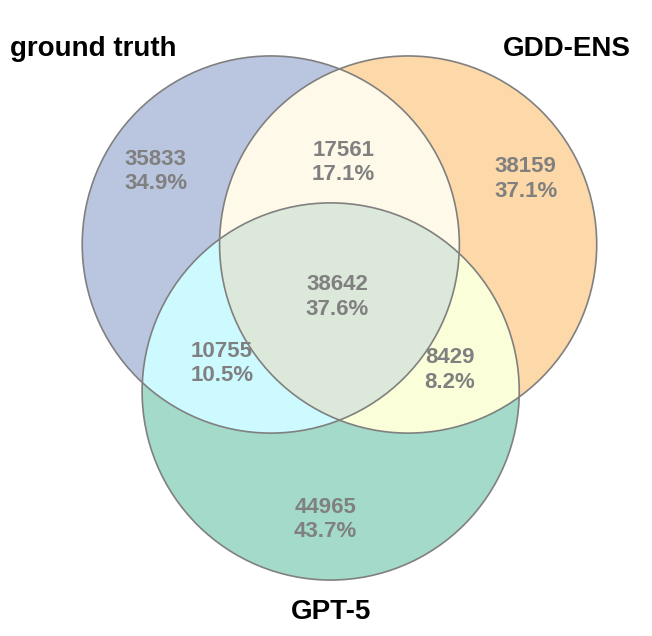

In [5]:
joint_pred_no_msk.rename(columns={'gpt_5_prediction1': 'GPT-5', 'GDD_prediction1': 'GDD-ENS'}, inplace=True)

myVenn(joint_pred_no_msk,'ground_truth','GDD-ENS','GPT-5', savepath="gdd_gpt_5_venn.pdf")
# myVenn(joint_pred_no_msk,'ground_truth','GDD_prediction1','medgemma_prediction1', savepath="gdd_medgemma_venn.png")